In [1]:
# Shows equilibria and dynamics for:
# 1) Continuous-time linear model: dn/dt = (αp - β) n
# 2) Discrete-time recursion EXACTLY as specified: n_{t+1} = (αp - β) n_t
# 3) Saturated (logistic-like) model: dn/dt = (αp - β) n - γ n^2 (finite equilibrium when αp>β)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Parameters ----------
n0 = 100
t_end = 10.0
dt = 0.01
t = np.arange(0.0, t_end + dt, dt)

# For saturated model
gamma = 0.8  # saturation strength (choose >0)

# Fitting the Discrete Recursion Model to Animal Data

When you have actual animal response data, you need to estimate the parameters (α, β, p) that best fit your observations. Here are several approaches:


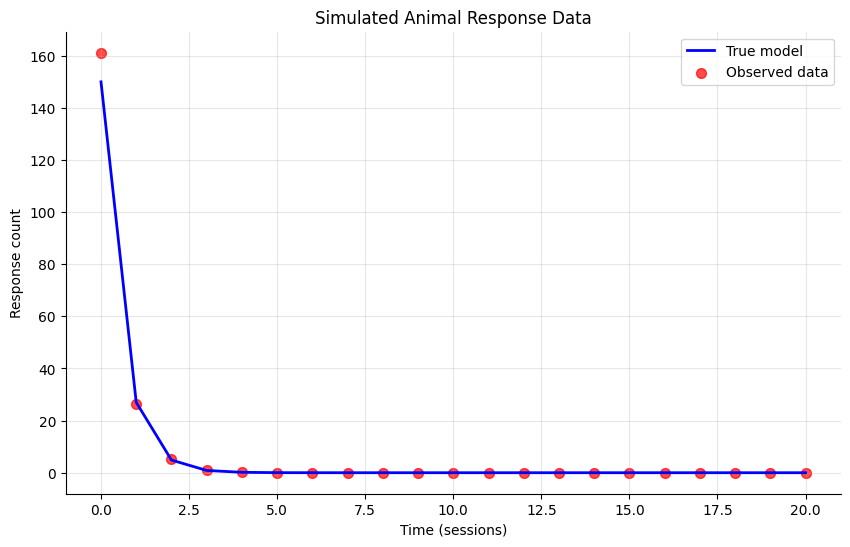

True parameters: α=1.8, β=0.9, p=0.6
True factor (αp-β): 0.180
Data range: 0.0 to 161.2


In [2]:
# First, let's create some simulated "animal data" to demonstrate fitting
np.random.seed(42)
T_data = 20
true_alpha = 1.8
true_beta = 0.9
true_p = 0.6
n0_true = 150

# Generate "true" trajectory
factor_true = true_alpha * true_p - true_beta
n_true = np.zeros(T_data + 1)
n_true[0] = n0_true
for k in range(T_data):
    n_true[k+1] = factor_true * n_true[k]

# Add measurement noise to simulate real data
noise_level = 0.15
observed_data = n_true + np.random.normal(0, noise_level * np.abs(n_true), len(n_true))
observed_data = np.maximum(observed_data, 0)  # Ensure non-negative responses

time_points = np.arange(0, T_data + 1)

plt.figure(figsize=(10, 6))
plt.plot(time_points, n_true, 'b-', linewidth=2, label='True model')
plt.scatter(time_points, observed_data, color='red', s=50, alpha=0.7, label='Observed data')
plt.title('Simulated Animal Response Data')
plt.xlabel('Time (sessions)')
plt.ylabel('Response count')
plt.legend()
plt.grid(True, alpha=0.3)
sns.despine()
plt.show()

print(f"True parameters: α={true_alpha}, β={true_beta}, p={true_p}")
print(f"True factor (αp-β): {factor_true:.3f}")
print(f"Data range: {observed_data.min():.1f} to {observed_data.max():.1f}")


## Approach 1: Least Squares Fitting

The most common approach is to minimize the sum of squared differences between observed and predicted values.


In [3]:
from scipy.optimize import minimize

def discrete_recursion_model(params, time_points, n0):
    """
    Generate predictions from the discrete recursion model
    
    Parameters:
    - params: [alpha, beta, p] - model parameters to fit
    - time_points: array of time points
    - n0: initial value
    
    Returns:
    - predicted values at each time point
    """
    alpha, beta, p = params
    factor = alpha * p - beta
    
    n_pred = np.zeros(len(time_points))
    n_pred[0] = n0
    
    for k in range(len(time_points) - 1):
        n_pred[k+1] = factor * n_pred[k]
    
    return n_pred

def sum_squared_error(params, observed_data, time_points, n0):
    """Calculate sum of squared errors between observed and predicted"""
    predicted = discrete_recursion_model(params, time_points, n0)
    return np.sum((observed_data - predicted)**2)

# Initial parameter guesses
initial_guess = [1.5, 0.8, 0.5]  # [alpha, beta, p]

# Parameter bounds (all should be positive)
bounds = [(0.1, 5.0),   # alpha bounds
          (0.1, 5.0),   # beta bounds  
          (0.01, 0.99)] # p bounds (probability, so 0-1)

# Fit the model
result = minimize(sum_squared_error, 
                 initial_guess, 
                 args=(observed_data, time_points, observed_data[0]),
                 bounds=bounds,
                 method='L-BFGS-B')

fitted_params = result.x
alpha_fit, beta_fit, p_fit = fitted_params

print("Least Squares Fitting Results:")
print(f"Fitted α: {alpha_fit:.3f} (true: {true_alpha})")
print(f"Fitted β: {beta_fit:.3f} (true: {true_beta})")
print(f"Fitted p: {p_fit:.3f} (true: {true_p})")
print(f"Fitted factor (αp-β): {alpha_fit*p_fit - beta_fit:.3f} (true: {factor_true:.3f})")
print(f"Sum of squared errors: {result.fun:.2f}")
print(f"Optimization successful: {result.success}")


Least Squares Fitting Results:
Fitted α: 1.728 (true: 1.8)
Fitted β: 0.755 (true: 0.9)
Fitted p: 0.533 (true: 0.6)
Fitted factor (αp-β): 0.166 (true: 0.180)
Sum of squared errors: 1.01
Optimization successful: True


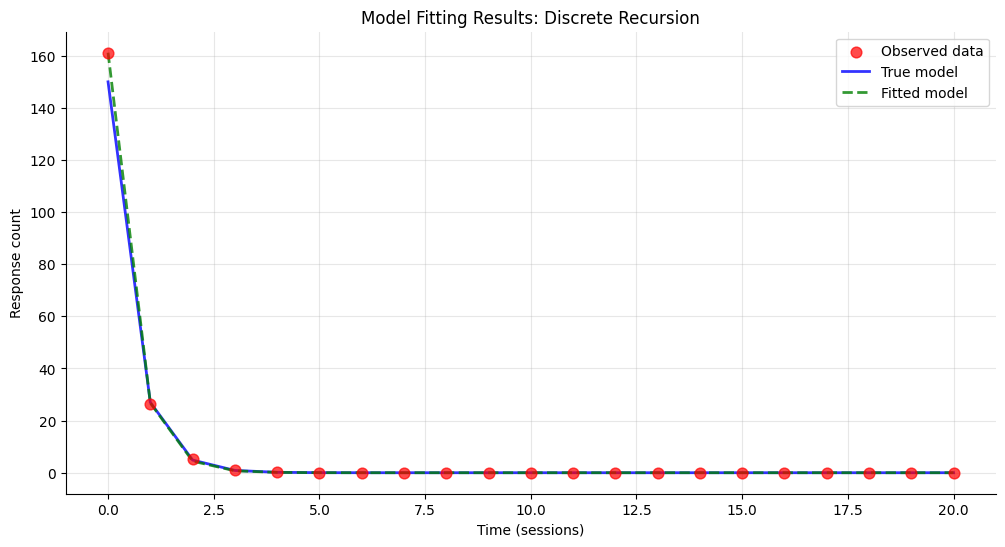

R-squared: 1.0000


In [4]:
# Plot the fitted model against the data
fitted_predictions = discrete_recursion_model(fitted_params, time_points, observed_data[0])

plt.figure(figsize=(12, 6))
plt.scatter(time_points, observed_data, color='red', s=60, alpha=0.7, label='Observed data', zorder=3)
plt.plot(time_points, n_true, 'b-', linewidth=2, label='True model', alpha=0.8)
plt.plot(time_points, fitted_predictions, 'g--', linewidth=2, label='Fitted model', alpha=0.8)
plt.title('Model Fitting Results: Discrete Recursion')
plt.xlabel('Time (sessions)')
plt.ylabel('Response count')
plt.legend()
plt.grid(True, alpha=0.3)
sns.despine()
plt.show()

# Calculate R-squared
ss_res = np.sum((observed_data - fitted_predictions)**2)
ss_tot = np.sum((observed_data - np.mean(observed_data))**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R-squared: {r_squared:.4f}")


## Approach 2: Maximum Likelihood Estimation

For count data (like response counts), you might want to assume a specific error distribution (e.g., Poisson) and use maximum likelihood estimation.


In [5]:
from scipy.stats import poisson

def negative_log_likelihood_poisson(params, observed_data, time_points, n0):
    """
    Calculate negative log-likelihood assuming Poisson distribution
    """
    predicted = discrete_recursion_model(params, time_points, n0)
    
    # Ensure predictions are positive for Poisson
    predicted = np.maximum(predicted, 0.1)
    
    # Calculate negative log-likelihood
    nll = 0
    for obs, pred in zip(observed_data, predicted):
        if obs >= 0:  # Only include valid observations
            nll -= poisson.logpmf(int(obs), pred)
    
    return nll

# Fit using maximum likelihood
result_mle = minimize(negative_log_likelihood_poisson, 
                     initial_guess, 
                     args=(observed_data, time_points, observed_data[0]),
                     bounds=bounds,
                     method='L-BFGS-B')

fitted_params_mle = result_mle.x
alpha_mle, beta_mle, p_mle = fitted_params_mle

print("Maximum Likelihood Estimation Results:")
print(f"Fitted α: {alpha_mle:.3f} (true: {true_alpha})")
print(f"Fitted β: {beta_mle:.3f} (true: {true_beta})")
print(f"Fitted p: {p_mle:.3f} (true: {true_p})")
print(f"Fitted factor (αp-β): {alpha_mle*p_mle - beta_mle:.3f} (true: {factor_true:.3f})")
print(f"Negative log-likelihood: {result_mle.fun:.2f}")
print(f"Optimization successful: {result_mle.success}")


Maximum Likelihood Estimation Results:
Fitted α: 1.470 (true: 1.8)
Fitted β: 0.890 (true: 0.9)
Fitted p: 0.489 (true: 0.6)
Fitted factor (αp-β): -0.171 (true: 0.180)
Negative log-likelihood: 130.58
Optimization successful: True


## Model Evaluation and Goodness of Fit

It's important to evaluate how well your model fits the data using multiple metrics:


Model Evaluation Metrics:

Least Squares Method:
  R_squared: 1.0000
  RMSE: 0.2190
  MAE: 0.0756
  AIC: -57.7769

Maximum Likelihood Method:
  R_squared: 0.8826
  RMSE: 11.7985
  MAE: 2.6948
  AIC: 109.6547


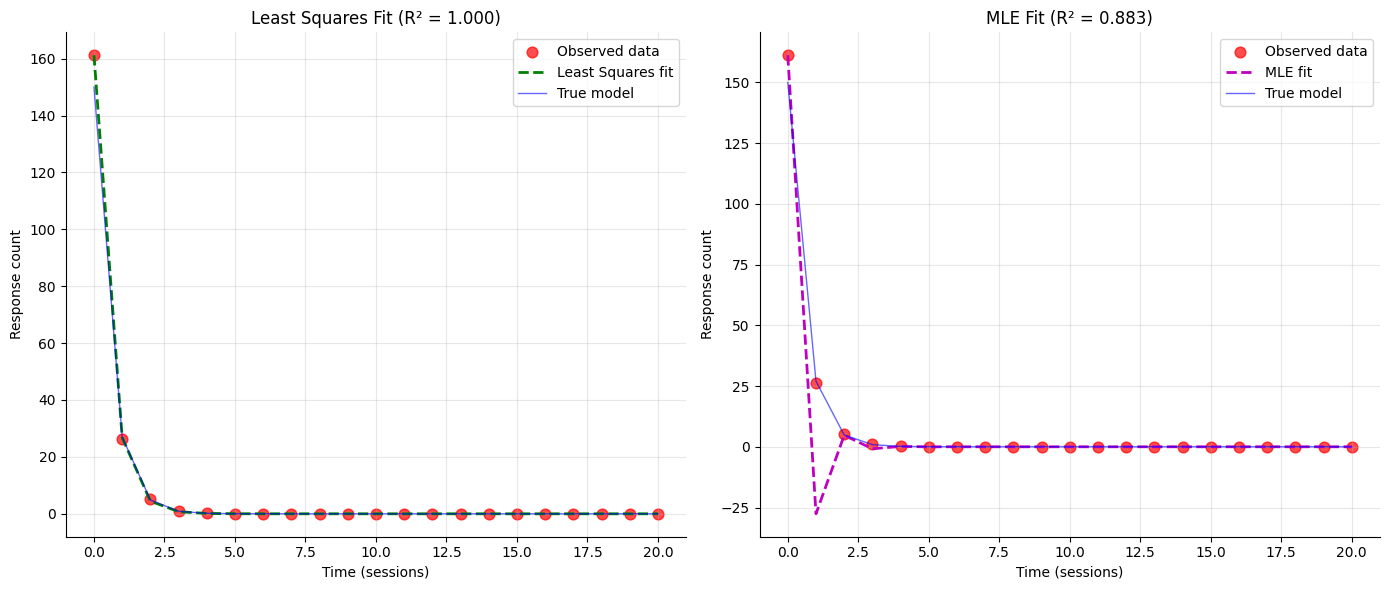

In [6]:
# Compare both fitting methods
fitted_predictions_mle = discrete_recursion_model(fitted_params_mle, time_points, observed_data[0])

# Calculate multiple goodness-of-fit metrics
def calculate_fit_metrics(observed, predicted):
    """Calculate various goodness-of-fit metrics"""
    residuals = observed - predicted
    
    # R-squared
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((observed - np.mean(observed))**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # Root Mean Square Error
    rmse = np.sqrt(np.mean(residuals**2))
    
    # Mean Absolute Error
    mae = np.mean(np.abs(residuals))
    
    # Akaike Information Criterion (AIC) - for model comparison
    n = len(observed)
    k = 3  # number of parameters (alpha, beta, p)
    aic = n * np.log(ss_res/n) + 2*k
    
    return {
        'R_squared': r_squared,
        'RMSE': rmse,
        'MAE': mae,
        'AIC': aic
    }

# Calculate metrics for both methods
metrics_ls = calculate_fit_metrics(observed_data, fitted_predictions)
metrics_mle = calculate_fit_metrics(observed_data, fitted_predictions_mle)

print("Model Evaluation Metrics:")
print("\nLeast Squares Method:")
for metric, value in metrics_ls.items():
    print(f"  {metric}: {value:.4f}")

print("\nMaximum Likelihood Method:")
for metric, value in metrics_mle.items():
    print(f"  {metric}: {value:.4f}")

# Compare both fits visually
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(time_points, observed_data, color='red', s=60, alpha=0.7, label='Observed data')
plt.plot(time_points, fitted_predictions, 'g--', linewidth=2, label='Least Squares fit')
plt.plot(time_points, n_true, 'b-', linewidth=1, alpha=0.6, label='True model')
plt.title(f'Least Squares Fit (R² = {metrics_ls["R_squared"]:.3f})')
plt.xlabel('Time (sessions)')
plt.ylabel('Response count')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(time_points, observed_data, color='red', s=60, alpha=0.7, label='Observed data')
plt.plot(time_points, fitted_predictions_mle, 'm--', linewidth=2, label='MLE fit')
plt.plot(time_points, n_true, 'b-', linewidth=1, alpha=0.6, label='True model')
plt.title(f'MLE Fit (R² = {metrics_mle["R_squared"]:.3f})')
plt.xlabel('Time (sessions)')
plt.ylabel('Response count')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
sns.despine()
plt.show()


## Practical Steps for Your Real Animal Data

When you have actual animal response data, follow these steps:

### 1. **Data Preparation**
```python
# Load your data (example format)
# time_points = np.array([0, 1, 2, 3, ...])  # session numbers
# response_counts = np.array([150, 140, 130, ...])  # responses per session
```

### 2. **Choose Your Approach**
- **Least Squares**: Good for continuous data with normal errors
- **Maximum Likelihood**: Better for count data or when you know the error distribution
- **Bayesian Methods**: If you have prior knowledge about parameters

### 3. **Set Reasonable Parameter Bounds**
- `α` (alpha): Usually > 0, represents response amplification
- `β` (beta): Usually > 0, represents baseline decay  
- `p` (probability): Between 0 and 1, represents reinforcement probability

### 4. **Try Multiple Initial Guesses**
Optimization can get stuck in local minima, so try several starting points:

```python
initial_guesses = [
    [1.0, 0.5, 0.3],
    [2.0, 1.0, 0.6], 
    [1.5, 0.8, 0.9]
]
```

### 5. **Validate Your Fit**
- Check residual plots for patterns
- Compare AIC values if testing multiple models
- Use cross-validation if you have enough data
- Consider biological plausibility of parameter values


In [15]:
# Basic demo of output
T = 12
steps = np.arange(0, T+1)
alpha = 2
beta = 1
p = 0.8 # 4:1 ratio = 5 responses to get 4 reinforcers = 5/4 = 1.25 RR
# p = 0.3 # 1:2 ratio = 3 responses to get 1 reinforcers = 3/1 = 3 RR

factor = alpha * p - beta  # multiplier for each step
n = np.zeros(T + 1)
n[0] = 100

for k in range(T):
    n[k+1] = factor * n[k]

n = np.round(n, 4)

resp_dict = dict(zip(steps, n))
resp_dict

{0: 100.0,
 1: 60.0,
 2: 36.0,
 3: 21.6,
 4: 12.96,
 5: 7.776,
 6: 4.6656,
 7: 2.7994,
 8: 1.6796,
 9: 1.0078,
 10: 0.6047,
 11: 0.3628,
 12: 0.2177}

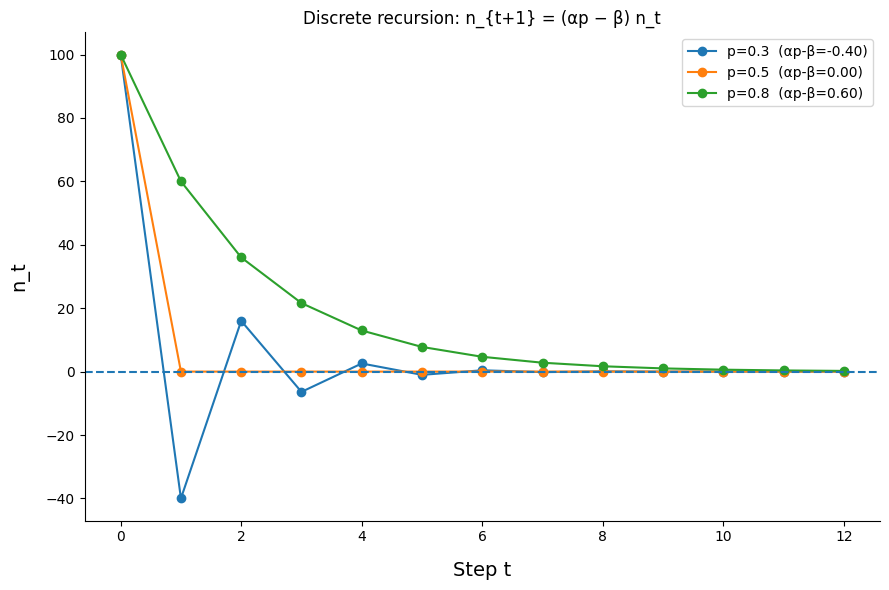

In [ ]:
# ---------- 1) Discrete-time recursion: n_{t+1} = (αp − β) n_t ----------
T = 12
steps = np.arange(0, T + 1)
n0 = 100
alpha = 2.0 # Twice as much as beta
beta = 1.0
p_values = [0.3, 0.5, 0.8]

plt.figure(figsize=(9, 6))
for p in p_values:
    factor = alpha * p - beta  # multiplier for each step
    n = np.zeros(T + 1)
    n[0] = n0
    for k in range(T):
        n[k+1] = factor * n[k]
    plt.plot(steps, n, marker='o', label=f"p={p}  (αp-β={factor:.2f})")
plt.axhline(0.0, linestyle="--")
plt.title("Discrete recursion: n_{t+1} = (αp − β) n_t")
plt.xlabel("Step t", fontsize=14, labelpad=12)
plt.ylabel("n_t", fontsize=14, labelpad=12)
plt.legend()
plt.tight_layout()
sns.despine(top=True, right=True)
plt.show()

In [24]:
def plot_discrete_recursion(p_values, alpha, beta, n0, T):
    steps = np.arange(T + 1)
    plt.figure(figsize=(9, 6))
    
    for p in p_values:
        factor = alpha * p - beta  # multiplier for each step
        n = np.zeros(T + 1)
        n[0] = n0
        for k in range(T):
            n[k+1] = factor * n[k]
        plt.plot(steps, n, marker='o', label=f"p={p}  (αp-β={factor:.2f})")
    
    plt.axhline(0.0, linestyle="--")
    plt.title(r"Discrete recursion: $n_{t+1} = (\alpha p − \beta) n_t$")
    plt.xlabel("Step t", fontsize=14, labelpad=12)
    plt.ylabel(r"$n_t$", fontsize=14, labelpad=12)
    plt.legend()
    plt.tight_layout()
    sns.despine(top=True, right=True)
    plt.show()

In [36]:
def plot_discrete_recursion_euler(p_values, alpha, beta, n0, T):
    """
    Discrete-time Euler update of dn/dt = (αp − β) n with Δt=1:
        n_{t+1} = (1 + (αp − β)) * n_t
    """
    steps = np.arange(T + 1)
    plt.figure(figsize=(9, 6))
    for p in p_values:
        r = alpha * p - beta
        mult = 1.0 + r
        n = np.zeros(T + 1)
        n[0] = n0
        for k in range(T):
            n[k+1] = mult * n[k]
        plt.plot(steps, n, marker='o', label=f"p={p}  r={r:.2f}, multiplier={mult:.2f}")
    plt.axhline(0.0, linestyle="--")
    plt.title(r"Discrete (Euler from ODE): $n_{t+1} = (1 + (\alpha p - \beta))\,n_t$")
    plt.xlabel("Step t", fontsize=14, labelpad=12)
    plt.ylabel(r"$n_t$", fontsize=14, labelpad=12)
    plt.legend()
    plt.tight_layout()
    sns.despine(top=True, right=True)
    plt.show()

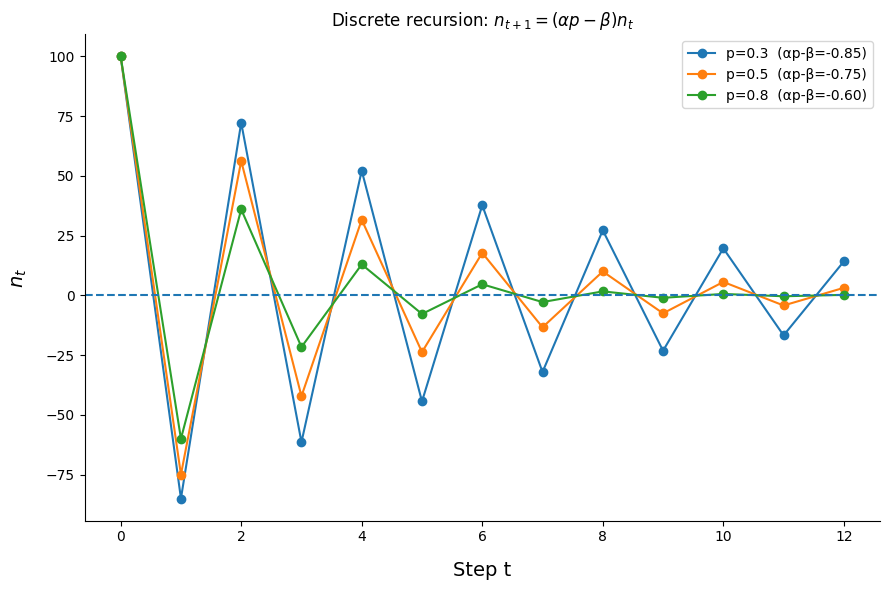

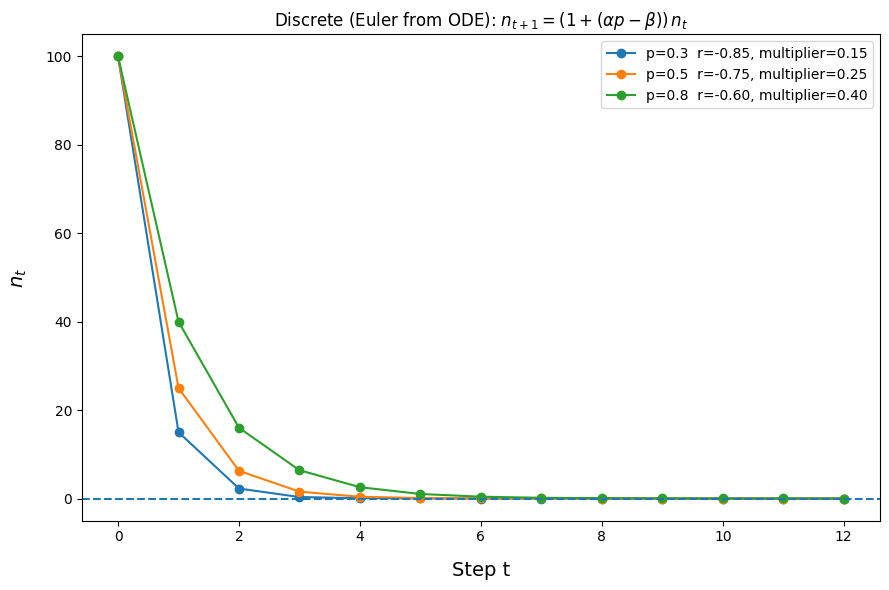

In [35]:
# ---------- 1) Discrete-time recursion: n_{t+1} = (αp − β) n_t ----------
plot_discrete_recursion(
    p_values = [0.3, 0.5, 0.8], 
    alpha = 0.5, # Half as much as beta, 
    beta = 1.0, 
    n0 = 100, 
    T = 12
)

plot_discrete_recursion_euler(
    p_values = [0.3, 0.5, 0.8], 
    alpha = 0.5, # Half as much as beta, 
    beta = 1.0, 
    n0 = 100, 
    T = 12
)

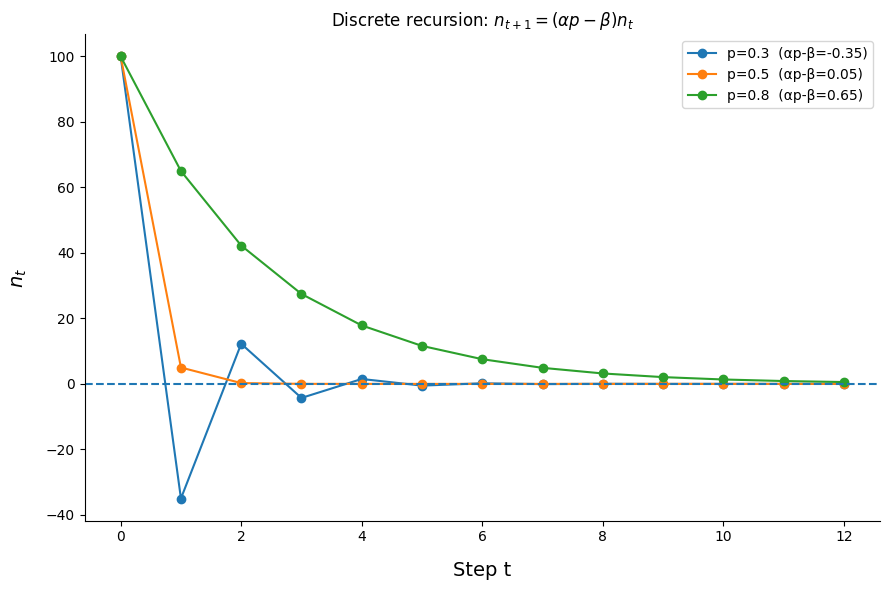

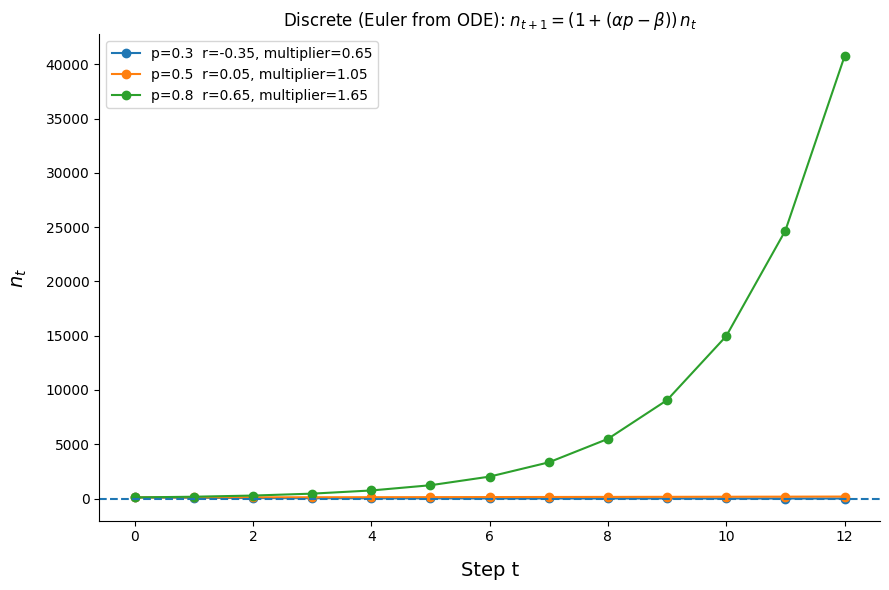

In [37]:
# ---------- 1) Discrete-time recursion: n_{t+1} = (αp − β) n_t ----------
plot_discrete_recursion(
    p_values = [0.3, 0.5, 0.8], 
    alpha = 2, 
    beta = 0.95, # Slightly less than 1
    n0 = 100, 
    T = 12
)

plot_discrete_recursion_euler(
    p_values = [0.3, 0.5, 0.8], 
    alpha = 2, 
    beta = 0.95, # Slightly less than 1
    n0 = 100, 
    T = 12
)

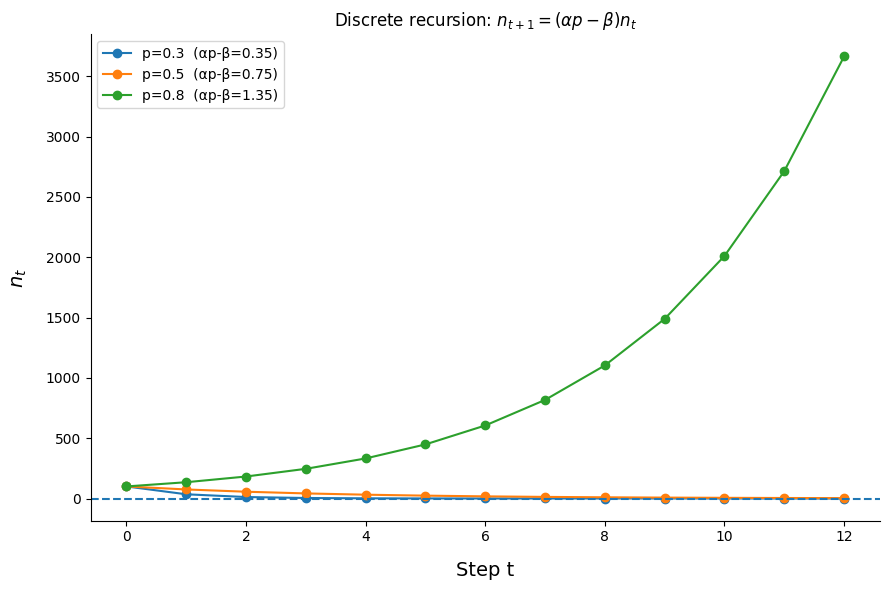

In [29]:
# ---------- 1) Discrete-time recursion: n_{t+1} = (αp − β) n_t ----------
plot_discrete_recursion(
    p_values = [0.3, 0.5, 0.8], 
    alpha = 2, 
    beta = 0.25, 
    n0 = 100, 
    T = 12
)

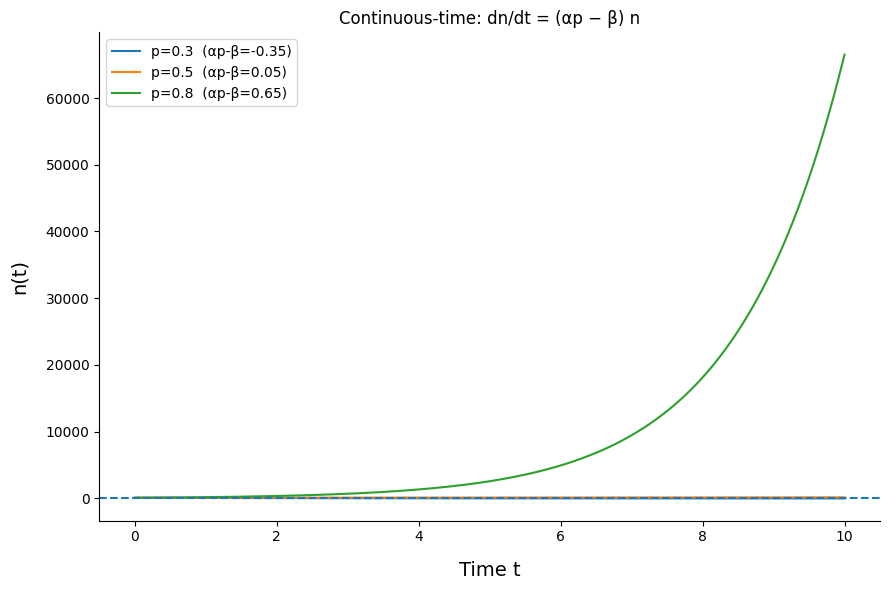

In [32]:
# ---------- 2) Continuous-time linear: dn/dt = (αp - β) n ----------
plt.figure(figsize=(9, 6))
for p in p_values:
    r = alpha * p - beta  # net growth rate
    n = n0 * np.exp(r * t)  # analytical solution
    plt.plot(t, n, label=f"p={p}  (αp-β={r:.2f})")
    # Equilibria: n*=0 (only finite eq). Show baseline line at 0.
plt.axhline(0.0, linestyle="--")
plt.title("Continuous-time: dn/dt = (αp − β) n")
plt.xlabel("Time t", fontsize=14, labelpad=12)
plt.ylabel("n(t)", fontsize=14, labelpad=12)
# plt.yscale("log")
plt.legend()
plt.tight_layout()
sns.despine(top=True, right=True)
plt.show()

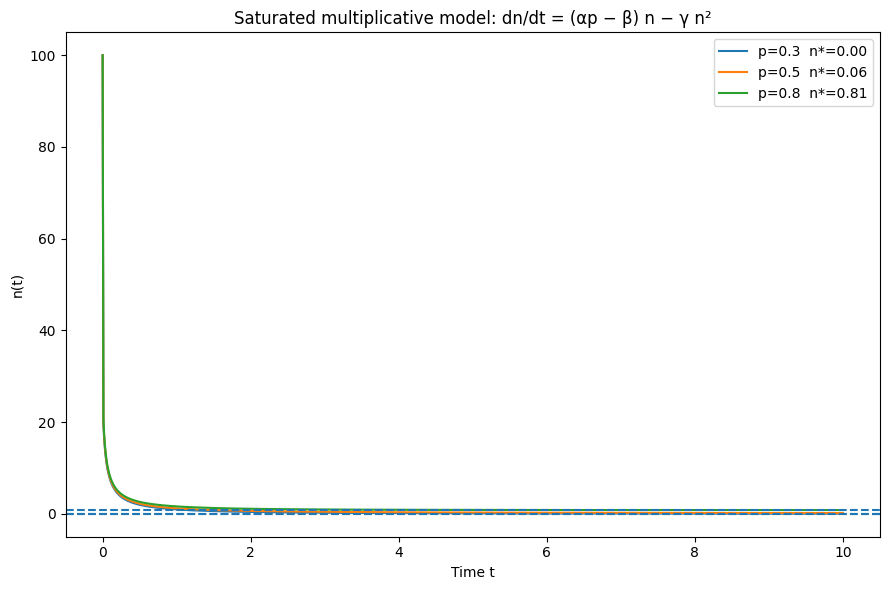

In [33]:
# ---------- 3) Saturated model: dn/dt = (αp − β) n − γ n^2 ----------
plt.figure(figsize=(9, 6))
for p in p_values:
    r = alpha * p - beta
    # Numerical integration (Euler) for the nonlinear case
    n = np.zeros_like(t)
    n[0] = n0
    for i in range(len(t) - 1):
        dn = (r * n[i] - gamma * n[i] * n[i]) * dt
        n[i+1] = max(0.0, n[i] + dn)  # enforce non-negativity for visualization
    # Equilibrium: n* = max{0, r/gamma}
    n_star = max(0.0, r / gamma)
    plt.plot(t, n, label=f"p={p}  n*={n_star:.2f}")
    plt.axhline(n_star, linestyle="--")
plt.title("Saturated multiplicative model: dn/dt = (αp − β) n − γ n²")
plt.xlabel("Time t")
plt.ylabel("n(t)")
plt.legend()
plt.tight_layout()
plt.show()


## Salivary Response Modeling

In [16]:
# Compact demo: Respondent conditioning under varying CS intensity (I) and learning rate (gamma)
# Three panels: recursion, difference (Euler with Δt≠1), and differential (closed-form solution).
# Each panel has two subplots: vary I (fixed gamma) and vary gamma (fixed I).

# ------------------------ Common settings ------------------------
R0 = 0.05                  # initial salivation magnitude
I_vals = [0.2, 0.5, 0.8]   # CS intensities to compare
gamma_vals = [0.2, 0.5, 0.8]  # learning rates to compare
T_trials = 20         # number of discrete trials to simulate for recursion
t_end = 10.0          # time horizon for differential/difference demonstrations
dt_diff = 0.2         # Δt for the difference-equation Euler update (≠ 1 to distinguish it)

# Time arrays
trials = np.arange(T_trials + 1)
t = np.arange(0.0, t_end + 1e-9, 0.01)  # smooth time for closed form
t_euler = np.arange(0.0, t_end + 1e-9, dt_diff)

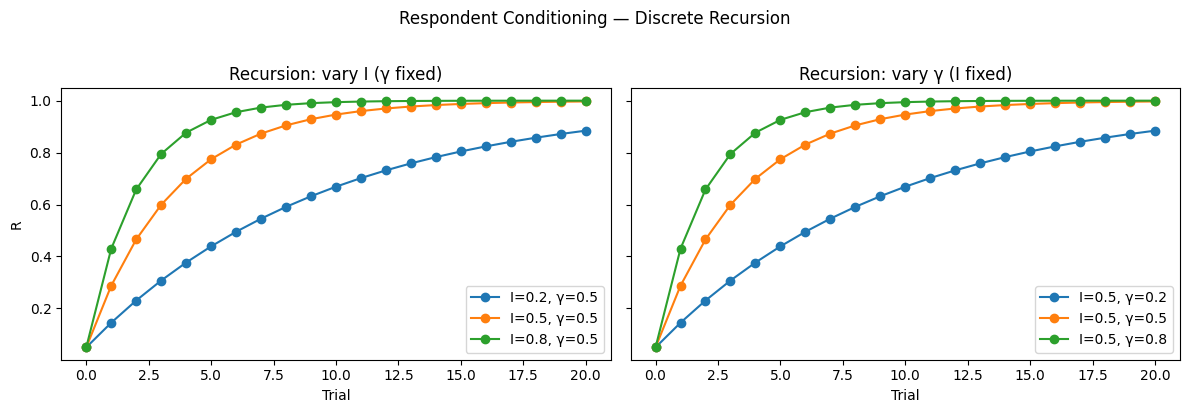

In [17]:
# ------------------------ 1) Recursion ------------------------
# R_{t+1} = R_t + γ I (1 - R_t)
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fixed_gamma = 0.5
fixed_I = 0.5

# (a) Vary I at fixed gamma
for I in I_vals:
    R = np.zeros(T_trials + 1)
    R[0] = R0
    for k in range(T_trials):
        R[k+1] = R[k] + fixed_gamma * I * (1.0 - R[k])
    axes1[0].plot(trials, R, marker='o', label=f"I={I}, γ={fixed_gamma}")
axes1[0].set_title("Recursion: vary I (γ fixed)")
axes1[0].set_xlabel("Trial")
axes1[0].set_ylabel("R")
axes1[0].legend()

# (b) Vary gamma at fixed I
for gamma in gamma_vals:
    R = np.zeros(T_trials + 1)
    R[0] = R0
    for k in range(T_trials):
        R[k+1] = R[k] + gamma * fixed_I * (1.0 - R[k])
    axes1[1].plot(trials, R, marker='o', label=f"I={fixed_I}, γ={gamma}")
axes1[1].set_title("Recursion: vary γ (I fixed)")
axes1[1].set_xlabel("Trial")
axes1[1].legend()

fig1.suptitle("Respondent Conditioning — Discrete Recursion", y=1.02, fontsize=12)
fig1.tight_layout()
plt.show()

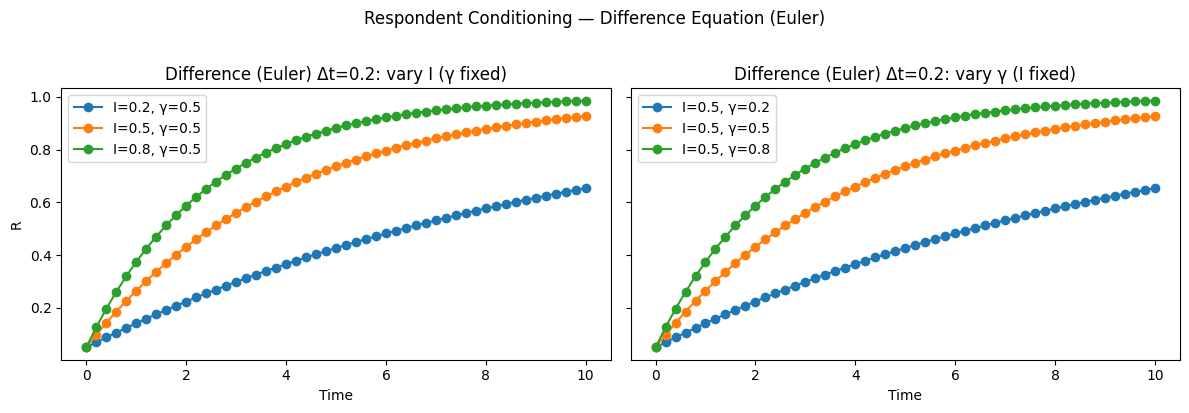

In [18]:
# ------------------------ 2) Difference equation ------------------------
# ΔR_t = γ I (1 - R_t) Δt  -> Euler update with Δt = dt_diff
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# (a) Vary I at fixed gamma
for I in I_vals:
    R = np.zeros_like(t_euler)
    R[0] = R0
    for k in range(len(t_euler)-1):
        dR = fixed_gamma * I * (1.0 - R[k]) * dt_diff
        R[k+1] = R[k] + dR
    axes2[0].plot(t_euler, R, marker='o', linestyle='-', label=f"I={I}, γ={fixed_gamma}")
axes2[0].set_title(f"Difference (Euler) Δt={dt_diff}: vary I (γ fixed)")
axes2[0].set_xlabel("Time")
axes2[0].set_ylabel("R")
axes2[0].legend()

# (b) Vary gamma at fixed I
for gamma in gamma_vals:
    R = np.zeros_like(t_euler)
    R[0] = R0
    for k in range(len(t_euler)-1):
        dR = gamma * fixed_I * (1.0 - R[k]) * dt_diff
        R[k+1] = R[k] + dR
    axes2[1].plot(t_euler, R, marker='o', linestyle='-', label=f"I={fixed_I}, γ={gamma}")
axes2[1].set_title(f"Difference (Euler) Δt={dt_diff}: vary γ (I fixed)")
axes2[1].set_xlabel("Time")
axes2[1].legend()

fig2.suptitle("Respondent Conditioning — Difference Equation (Euler)", y=1.02, fontsize=12)
fig2.tight_layout()
plt.show()

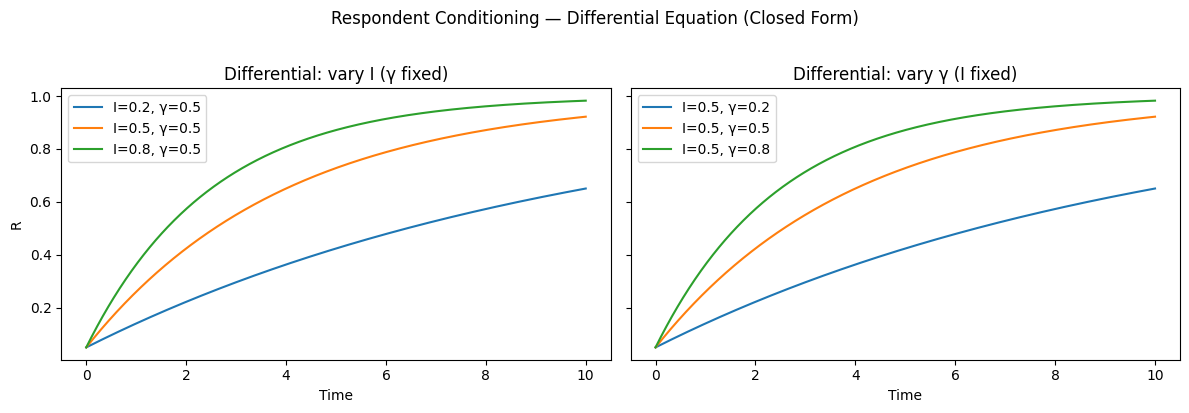

In [19]:
# ------------------------ 3) Differential equation (closed-form) ------------------------
# dR/dt = γ I (1 - R)  ->  R(t) = 1 - (1 - R0) exp(-γ I t)
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# (a) Vary I at fixed gamma
for I in I_vals:
    R = 1.0 - (1.0 - R0) * np.exp(-fixed_gamma * I * t)
    axes3[0].plot(t, R, label=f"I={I}, γ={fixed_gamma}")
axes3[0].set_title("Differential: vary I (γ fixed)")
axes3[0].set_xlabel("Time")
axes3[0].set_ylabel("R")
axes3[0].legend()

# (b) Vary gamma at fixed I
for gamma in gamma_vals:
    R = 1.0 - (1.0 - R0) * np.exp(-gamma * fixed_I * t)
    axes3[1].plot(t, R, label=f"I={fixed_I}, γ={gamma}")
axes3[1].set_title("Differential: vary γ (I fixed)")
axes3[1].set_xlabel("Time")
axes3[1].legend()

fig3.suptitle("Respondent Conditioning — Differential Equation (Closed Form)", y=1.02, fontsize=12)
fig3.tight_layout()
plt.show()


In [32]:
# Plotly 3D interactive meshes for respondent conditioning
# We create three figures (recursion, difference/Euler, differential/closed-form).
# Each figure shows a 3x3 grid over I (CS intensity) and gamma (learning rate), with
# a time slider to scrub through trials/time. The surface z = R(I, gamma, t).

import numpy as np
import plotly.graph_objects as go

# ---------------- Common parameters ----------------
R0 = 0.05
I_vals = np.array([0.2, 0.5, 0.8])
gamma_vals = np.array([0.2, 0.5, 0.8])

# Build a 2D meshgrid for I, gamma
I_grid, G_grid = np.meshgrid(I_vals, gamma_vals)  # shape (3,3)

# ---------------- 1) Recursion ----------------
# R_{t+1} = R_t + gamma * I * (1 - R_t), with trial index t = 0..T
T_trials = 20

def recursion_surface_at_trial(t_idx):
    # Iterate t_idx steps for each (I, gamma) on the grid
    R = np.full_like(I_grid, R0, dtype=float)
    for _ in range(t_idx):
        R = R + G_grid * I_grid * (1.0 - R)
    return R

frames_rec = []
for k in range(T_trials + 1):
    Z = recursion_surface_at_trial(k)
    frames_rec.append(go.Frame(data=[go.Surface(z=Z, x=I_grid, y=G_grid, showscale=False)],
                               name=f"trial_{k}"))

fig_rec = go.Figure(
    data=[go.Surface(z=recursion_surface_at_trial(0), x=I_grid, y=G_grid, showscale=True)],
    layout=go.Layout(
        height=600,
        width=1000,
        title="Respondent Conditioning — Recursion<br>z = R, x = I, y = γ (trial slider)",
        scene=dict(
            xaxis_title="I (CS intensity)",
            yaxis_title="γ (learning rate)",
            zaxis_title="R (salivation)",
            zaxis=dict(range=[0, 1]),  # lock z limits
            aspectmode='cube'
        ),
        updatemenus=[dict(type="buttons",
                          buttons=[dict(label="Play",
                                        method="animate",
                                        args=[None, dict(frame=dict(duration=200, redraw=True),
                                                         fromcurrent=True, transition=dict(duration=0))]),
                                   dict(label="Pause",
                                        method="animate",
                                        args=[[None], dict(frame=dict(duration=0, redraw=False),
                                                           mode="immediate")])])],
        sliders=[dict(
            steps=[dict(method="animate",
                        args=[[f"trial_{k}"],
                              dict(mode="immediate",
                                   frame=dict(duration=0, redraw=True),
                                   transition=dict(duration=0))],
                        label=str(k))
                   for k in range(T_trials + 1)],
            currentvalue=dict(prefix="Trial: ")
        )]
    ),
    frames=frames_rec
)

fig_rec.show()

In [31]:
# ---------------- 2) Difference (Euler with Δt) ----------------
dt = 0.2
t_end = 10.0
time_euler = np.arange(0.0, t_end + 1e-9, dt)

def difference_surface_at_index(idx):
    # Euler stepping up to idx for each grid point
    R = np.full_like(I_grid, R0, dtype=float)
    for _ in range(idx):
        dR = G_grid * I_grid * (1.0 - R) * dt
        R = R + dR
    return R

frames_diff = []
for i in range(len(time_euler)):
    Z = difference_surface_at_index(i)
    frames_diff.append(go.Frame(data=[go.Surface(z=Z, x=I_grid, y=G_grid, showscale=False)],
                                name=f"tidx_{i}"))

fig_diff = go.Figure(
    data=[go.Surface(z=difference_surface_at_index(0), x=I_grid, y=G_grid, showscale=True)],
    layout=go.Layout(
        height=600,
        width=1000,
        title=f"Respondent Conditioning — Difference (Euler Δt={dt})<br>z = R, x = I, y = γ (time slider)",
        scene=dict(
            xaxis_title="I (CS intensity)",
            yaxis_title="γ (learning rate)",
            zaxis_title="R (salivation)",
            zaxis=dict(range=[0, 1]),  # lock z limits
            aspectmode='cube'
        ),
        updatemenus=[dict(type="buttons",
                          buttons=[dict(label="Play",
                                        method="animate",
                                        args=[None, dict(frame=dict(duration=120, redraw=True),
                                                         fromcurrent=True, transition=dict(duration=0))]),
                                   dict(label="Pause",
                                        method="animate",
                                        args=[[None], dict(frame=dict(duration=0, redraw=False),
                                                           mode="immediate")])])],
        sliders=[dict(
            steps=[dict(method="animate",
                        args=[[f"tidx_{i}"],
                              dict(mode="immediate",
                                   frame=dict(duration=0, redraw=True),
                                   transition=dict(duration=0))],
                        label=f"{time_euler[i]:.1f}")
                   for i in range(len(time_euler))],
            currentvalue=dict(prefix="Time: ")
        )]
    ),
    frames=frames_diff
)

fig_diff.show()

In [30]:
# ---------------- 3) Differential (closed-form) ----------------
# dR/dt = γ I (1 - R)  =>  R(t) = 1 - (1 - R0) exp(-γ I t)
time_ct = np.linspace(0.0, 10.0, 51)

def differential_surface_at_time(tval):
    return 1.0 - (1.0 - R0) * np.exp(-G_grid * I_grid * tval)

frames_ct = []
for i, tval in enumerate(time_ct):
    Z = differential_surface_at_time(tval)
    frames_ct.append(go.Frame(data=[go.Surface(z=Z, x=I_grid, y=G_grid, showscale=False)],
                              name=f"t_{i}"))

fig_ct = go.Figure(
    data=[go.Surface(z=differential_surface_at_time(0.0), x=I_grid, y=G_grid, showscale=True)],
    layout=go.Layout(
        height=600,
        width=1000,
        title="Respondent Conditioning — Differential (Closed Form)<br>z = R, x = I, y = γ (time slider)",
        scene=dict(
            xaxis_title="I (CS intensity)",
            yaxis_title="γ (learning rate)",
            zaxis_title="R (salivation)",
            zaxis=dict(range=[0, 1]),  # lock z limits
            aspectmode='cube'
        ),
        updatemenus=[dict(type="buttons",
                          buttons=[dict(label="Play",
                                        method="animate",
                                        args=[None, dict(frame=dict(duration=120, redraw=True),
                                                         fromcurrent=True, transition=dict(duration=0))]),
                                   dict(label="Pause",
                                        method="animate",
                                        args=[[None], dict(frame=dict(duration=0, redraw=False),
                                                           mode="immediate")])])],
        sliders=[dict(
            steps=[dict(method="animate",
                        args=[[f"t_{i}"],
                              dict(mode="immediate",
                                   frame=dict(duration=0, redraw=True),
                                   transition=dict(duration=0))],
                        label=f"{time_ct[i]:.1f}")
                   for i in range(len(time_ct))],
            currentvalue=dict(prefix="Time: ")
        )]
    ),
    frames=frames_ct
)

fig_ct.show()
